#1~4で最も高いスコアを記録したデータ・モデルを用いて、さらに改良を行う。

In [ ]:
#import
import pandas as pd
from sklearn.model_selection import train_test_split  #データの分割

from sklearn.preprocessing import StandardScaler #標準化
from sklearn.model_selection import KFold #K分割交差検証
from sklearn.model_selection import cross_validate  #K分割交差検証

from sklearn.linear_model import LinearRegression #回帰
from sklearn.preprocessing import PolynomialFeatures  #交互作用特徴量
from sklearn.linear_model import Ridge  #リッジ回帰
from sklearn.linear_model import Lasso  #ラッソ回帰

from statsmodels.stats.outliers_influence import variance_inflation_factor  #VIF
from sklearn.decomposition import PCA  #PCA

import os
os.environ['OMP_NUM_THREADS'] = '6'  #クラスタリング実行時に警告が出ることを防ぐ
from sklearn.cluster import KMeans  #クラスタリング

In [3]:
#データフレームの読み込み
'''
以降はスコアが最高であったdf3を用いて分析を行う。
sc_x,df_yはdf3を基に作成する。
ただし、必要があればdf1, df2も利用する。
'''
df3 = pd.read_csv('datafiles/df3_lowered_VIF.csv')

sc_x = df3.drop(['SalePrice'], axis = 1)
df_y = pd.DataFrame(df3['SalePrice'])

In [4]:
#K分割交差検証のための準備
kf=KFold(n_splits=5, shuffle=True, random_state=0)

In [5]:
#リッジ回帰のalphaを90~1000で最適化（以前は１～100までの自然数で実験しただけであった）
best_ridgescore = 0
best_alpha = 0

for i in range(90,1000):
    ridgeModel = Ridge(random_state = 0, alpha = i)
    all_result = cross_validate(ridgeModel, sc_x, df_y, cv = kf, scoring = 'r2', return_train_score = True)
    result = sum(all_result['test_score'])/len(all_result['test_score'])
    if result > best_ridgescore:
        best_ridgescore = result
        best_alpha = i
print(f'最適な正則化項＝{best_alpha}　最高スコア＝{best_ridgescore}')

最適な正則化項＝478　最高スコア＝0.8205844141029276


In [6]:
#リッジ回帰のalphaを478付近でより細かく最適化（以前は１～100までの自然数で実験しただけであった）
best_ridgescore = 0
best_alpha = 0

for i in range(47700,47900):
    num = i/100
    ridgeModel = Ridge(random_state = 0, alpha = num)
    all_result = cross_validate(ridgeModel, sc_x, df_y, cv = kf, scoring = 'r2', return_train_score = True)
    result = sum(all_result['test_score'])/len(all_result['test_score'])
    if result > best_ridgescore:
        best_ridgescore = result
        best_alpha = num
print(f'最適な正則化項＝{best_alpha}　最高スコア＝{best_ridgescore}')


最適な正則化項＝478.14　最高スコア＝0.8205844152693619


In [7]:
#4_analysis_2においてVIFを行の削除により下げたスコアの最高値   0.7971109145093968よりもスコアが向上した。

In [8]:
#引き続き、特徴量の最適化を行う。
model5 = Ridge(random_state = 0, alpha = best_alpha)
model5.fit(sc_x, df_y)
coef_df = pd.DataFrame({
    'features':sc_x.columns,
    'Coefficient': model5.coef_
})
coef_df.sort_values('Coefficient', ascending=False)

,features,Coefficient
2,OverallQual,10957.831681
8,1stFlrSF,9102.571118
16,TotRmsAbvGrd,7851.661035
195,Neighborhood_NoRidge,6941.700492
196,Neighborhood_NridgHt,6872.611172
...,...,...
75,BldgType_TwnhsE,-3760.381477
127,KitchenQual_Gd,-4433.561103
48,BsmtQual_Gd,-4760.329032
97,PoolQC_Gd,-4799.248606


In [36]:
'''
今回のデータセットでは各特徴量の意味が明確であるから、ドメイン知識に基づいて仮説検証を行う。
以下が検証すべき仮説である。

・都会の一戸建ては価格が高い。
・好立地で敷地面積が大きいと価格は高くなりやすい。
・都会の中でも住宅街のような閑静なエリアは価格が高い。
・寒い地域で暖房設備に欠陥があったり、断熱性の弱い外壁素材であったりすると価格が低い。
・プール、地下室など生活のために必須ではない要素がある家には富裕層が住んでいる可能性が高いため価格も高い。
・特に立地・住宅の種類は、他の様々な特徴量と関連性が強そうである。

ゆえに、以下の順番で検証を行う。
1.Neighborhood（立地）に関連する各ダミー変数列と、各特徴量の交互作用特徴量を作成
2.MSSubClass（住宅の種類）と、各特徴量の交互作用特徴量を作成
3.BsmtQual_NA（地下室の有無）、WoodDeckSF、OpenPorchSF、EnclosedPorch、3SsnPorch、ScreenPorch、
  PoolArea、MiscFeature（家に付随する必須ではない機能）は関連性が高い可能性があるので、
  PCAにより特徴量を統合することや、クラスタリングでの分類を目指す。

検証のために必要な特徴量を削除してしまっていたので、以下ではdf1（特徴量削除前のデータフレーム）を用いる。
'''
df1 = pd.read_csv('datafiles/df1_all_col.csv')

sc_x = df1.drop(['SalePrice'], axis = 1)
df_y = pd.DataFrame(df3['SalePrice'])


In [37]:
result = cross_validate(model5, sc_x, df_y, cv = kf, scoring = 'r2' , return_train_score = True)
print(f'完成したmodel2のスコア＝{sum(result['test_score'])/len(result['test_score'])}')

完成したmodel2のスコア＝0.8192748628393769


In [38]:
#元の列をリスト化しておく
original_cols = list(sc_x.columns)

#1の仮説検証

In [ ]:
#sc_x1を１の仮説検証のためのデータフレームとする。
sc_x1 = sc_x.copy()

Neighborhood_cols = []
for c in original_cols:
    if 'Neighborhood' in c:
        Neighborhood_cols.append(c)

not_neighborhood_cols = list(set(original_cols) - set(Neighborhood_cols))

#Neighborhood_colsそれぞれに対して多項式特徴量を追加
new_cols = {}
for c1 in Neighborhood_cols:
    for c2 in not_neighborhood_cols:
        col_name = c1 + '_' + c2
        new_cols[col_name] = sc_x1[c1] * sc_x1[c2]
sc_x1 = pd.concat([sc_x1, pd.DataFrame(new_cols, index=sc_x1.index)], axis=1)

In [40]:
#作成したデータで学習
model5 = Ridge(alpha = best_alpha)
result = cross_validate(model5, sc_x1, df_y, cv = kf, scoring = 'r2', return_train_score = True)
print(f'完成したmodel5のスコア＝{sum(result['test_score'])/len(result['test_score'])}')

完成したmodel5のスコア＝0.838013880006198


In [47]:
#1により、スコアは誤差程度向上した。ただし、余計な特徴量を非常に多く追加してしまった可能性がある。
#したがって、効果の低い特徴量の係数を０にできるラッソ回帰が有効である可能性がある。

#一旦alpha=478のラッソ回帰モデルで学習
model6 = Lasso(alpha = 478, random_state = 0)
result = cross_validate(model6, sc_x1, df_y, cv = kf, scoring = 'r2', return_train_score = True)
print(f'完成したmodel3のスコア＝{sum(result['test_score'])/len(result['test_score'])}')

完成したmodel3のスコア＝0.84303517031005


In [49]:
#ゆえに、ラッソ回帰によりスコアが大幅に向上した。

#最適なalphaの探索
best_lassoscore = 0
best_alpha = 0
#alpha（Fの係数）を100,200,…,1000まで変化させて実験
for i in range(1,11):
    num = i*100
    lassoModel = Lasso(random_state = 0, alpha = num)
    all_result = cross_validate(lassoModel, sc_x1, df_y, cv = kf, scoring = 'r2', return_train_score = True)
    result = sum(all_result['test_score'])/len(all_result['test_score'])
    if result > best_lassoscore:
        best_lassoscore = result
        best_alpha = num
print(f'最適な正則化項＝{best_alpha}　ラッソ回帰の最高スコア＝{best_lassoscore}')

c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.229e+09, tolerance: 7.582e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.094e+09, tolerance: 7.034e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.264e+09, toleranc

最適な正則化項＝300　ラッソ回帰の最高スコア＝0.844173171400673


In [50]:
#最適なalphaの探索
#alpha（Fの係数）を250,260,…,340,350まで変化させて実験
for i in range(25,36):
    num = i*10
    lassoModel = Lasso(random_state = 0, alpha = num)
    all_result = cross_validate(lassoModel, sc_x1, df_y, cv = kf, scoring = 'r2', return_train_score = True)
    result = sum(all_result['test_score'])/len(all_result['test_score'])
    if result > best_lassoscore:
        best_lassoscore = result
        best_alpha = num
print(f'最適な正則化項＝{best_alpha}　ラッソ回帰の最高スコア＝{best_lassoscore}')

最適な正則化項＝330　ラッソ回帰の最高スコア＝0.8443803597436469


In [52]:
#最適なalphaの探索
#alpha（Fの係数）を325,326,…,335まで変化させて実験
for i in range(325,335):
    num = i
    lassoModel = Lasso(random_state = 0, alpha = num)
    all_result = cross_validate(lassoModel, sc_x1, df_y, cv = kf, scoring = 'r2', return_train_score = True)
    result = sum(all_result['test_score'])/len(all_result['test_score'])
    if result > best_lassoscore:
        best_lassoscore = result
        best_alpha = num
print(f'最適な正則化項＝{best_alpha}　ラッソ回帰の最高スコア＝{best_lassoscore}')

model6 =  Lasso(random_state = 0, alpha = best_alpha)

最適な正則化項＝329　ラッソ回帰の最高スコア＝0.8443813089776464


In [ ]:
#1により、ラッソ回帰のスコアがリッジ回帰を上回った。
#以降はこのmodel6（正則化項＝329のラッソ回帰モデル）と、1により特徴量を追加したデータフレームsc_x1を利用する。

#2の仮説検証

In [53]:
#sc_x2を2の仮説検証のためのデータフレームとする。
sc_x2 = sc_x1.copy()

#多項式特徴量を追加
new_cols = {}
for c in original_cols:
    if c != 'MSSubClass':
        col_name = 'MSSubClass_' + c
        new_cols[col_name] = sc_x2['MSSubClass'] * sc_x2[c]
sc_x2 = pd.concat([sc_x2, pd.DataFrame(new_cols, index=sc_x2.index)], axis=1)

In [55]:
#作成したデータで学習
result = cross_validate(model6, sc_x2, df_y, cv = kf, scoring = 'r2', return_train_score = True)
print(f'完成したmodel6のスコア＝{sum(result['test_score'])/len(result['test_score'])}')

完成したmodel6のスコア＝0.8409356168854382


In [56]:
#2によりスコアが低下した。よって2での改変は棄却する。
#以降はmodel6とsc_x1を利用する。

#3の仮説検証

In [62]:
#PCAする特徴量の指定
to_PCA = ['BsmtQual_NA', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea']
for c in original_cols:
    if 'MiscFeature' in c:
        to_PCA.append(c)

In [63]:
#主成分分析を実施
sc_x3 = sc_x1.copy()

#累積寄与率の閾値を0.8として、n_componentsを設定
#適切なPCAのための特徴量数の設定
thred = 0.8
final_num = 0
PCAmodel = PCA(whiten = True)
PCAmodel.fit(sc_x3[to_PCA])
ratio =PCAmodel.explained_variance_ratio_
for i in range(len(ratio)):
    ruiseki = sum(ratio[0:i+1])    #i+1個めの特徴量までの累積寄与率
    if ruiseki >= thred:   #i+1個めの特徴量において初めて累積寄与率がthredを超えるならば
        final_num = i + 1   #特徴量はi+1個必要である
        break
print(f'PCAにより作成された特徴量数＝{final_num}')


#最適な特徴量数で、主成分分析の実施
PCAmodel = PCA(n_components = final_num, whiten = True)
PCAmodel.fit(sc_x3[to_PCA])

PCAにより作成された特徴量数＝8


,n_components,8
,copy,True
,whiten,True
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [64]:
len(to_PCA)

11

In [66]:
#主成分によるデータフレームをPCA_sc_x3とする
PCA_sc_x3 = PCAmodel.transform(sc_x3[to_PCA])
PCA_sc_x3 = pd.DataFrame(PCA_sc_x3)
col_name = []
for i in range(final_num):
    name = 'PCA_' + str(i)
    col_name.append(name)
PCA_sc_x3.columns = col_name

sc_x3 = pd.concat([sc_x3, PCA_sc_x3], axis = 1)

In [67]:
#作成したデータで学習
result = cross_validate(model6, sc_x3, df_y, cv = kf, scoring = 'r2', return_train_score = True)
print(f'完成したmodel6のスコア＝{sum(result['test_score'])/len(result['test_score'])}')

完成したmodel6のスコア＝0.8443805559151514


In [ ]:
#仮説３検証前のスコア＝0.844381 / 検証後のスコア＝0.844380　よって誤差程度の低下が見られた。
#よって、PCAで追加した特徴量は棄却する。
#以降はmodel6とsc_x1を利用する。

In [99]:
#クラスタリングによる分析
#３グループで実験
cluster_model = KMeans(n_clusters = 3, random_state = 0)
cluster_model.fit(df1)  #目的変数の列も含めてデータの全体的な傾向を見たいので、df1を使用
df_cluster = df1.copy()
df_cluster['cluster'] = cluster_model.labels_
df_cluster.head(50)

c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,GarageFinish_NA,GarageFinish_RFn,GarageFinish_Unf,SalePrice,cluster
0,0.073375,0.212877,-0.207142,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,-0.288653,...,-0.02618,-0.037037,-0.02618,-0.02618,-0.037037,-0.242360,1.568348,-0.841191,208500.0,2
1,-0.872563,0.645747,-0.091886,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,-0.288653,...,-0.02618,-0.037037,-0.02618,-0.02618,-0.037037,-0.242360,1.568348,-0.841191,181500.0,2
2,0.073375,0.299451,0.073480,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,-0.288653,...,-0.02618,-0.037037,-0.02618,-0.02618,-0.037037,-0.242360,1.568348,-0.841191,223500.0,2
3,0.309859,0.068587,-0.096897,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,-0.288653,...,-0.02618,-0.037037,-0.02618,-0.02618,-0.037037,-0.242360,-0.637614,1.188791,140000.0,0
4,0.073375,0.761179,0.375148,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,-0.288653,...,-0.02618,-0.037037,-0.02618,-0.02618,-0.037037,-0.242360,1.568348,-0.841191,250000.0,2
5,-0.163109,0.790037,0.360616,-0.795151,-0.517200,0.719786,0.491040,-0.570750,0.632450,-0.288653,...,-0.02618,-0.037037,-0.02618,-0.02618,-0.037037,-0.242360,-0.637614,1.188791,143000.0,0
6,-0.872563,0.501457,-0.043379,1.374795,-0.517200,1.084115,0.975575,0.458754,2.029558,-0.288653,...,-0.02618,-0.037037,-0.02618,-0.02618,-0.037037,-0.242360,1.568348,-0.841191,307000.0,1
7,0.073375,-1.662893,-0.013513,0.651479,0.381743,0.057371,-0.574938,0.757643,0.910994,-0.090220,...,-0.02618,-0.037037,-0.02618,-0.02618,-0.037037,-0.242360,1.568348,-0.841191,200000.0,2
8,-0.163109,-0.191135,-0.440659,0.651479,-0.517200,-1.333700,-1.689368,-0.570750,-0.973018,-0.288653,...,-0.02618,-0.037037,-0.02618,-0.02618,-0.037037,-0.242360,-0.637614,1.188791,129900.0,0
9,3.147673,-0.219993,-0.310370,-0.795151,0.381743,-1.068734,-1.689368,-0.570750,0.893448,-0.288653,...,-0.02618,-0.037037,-0.02618,-0.02618,-0.037037,-0.242360,1.568348,-0.841191,118000.0,0


In [100]:
display(df_cluster.groupby('cluster').mean().T)

cluster,0,1,2
MSSubClass,0.049018,-0.248835,-0.017446
LotFrontage,-0.102868,0.634926,0.011514
LotArea,-0.177111,0.604113,0.128705
OverallQual,-0.617257,1.706314,0.537413
OverallCond,0.119130,-0.202570,-0.131939
...,...,...,...
Condition2_RRNn,0.030471,-0.037037,-0.037037
GarageFinish_NA,0.183033,-0.242360,-0.218045
GarageFinish_RFn,-0.249298,-0.067740,0.385560
GarageFinish_Unf,0.436101,-0.672026,-0.498467


cluster
0    Axes(0.125,0.11;0.775x0.77)
1    Axes(0.125,0.11;0.775x0.77)
2    Axes(0.125,0.11;0.775x0.77)
dtype: object

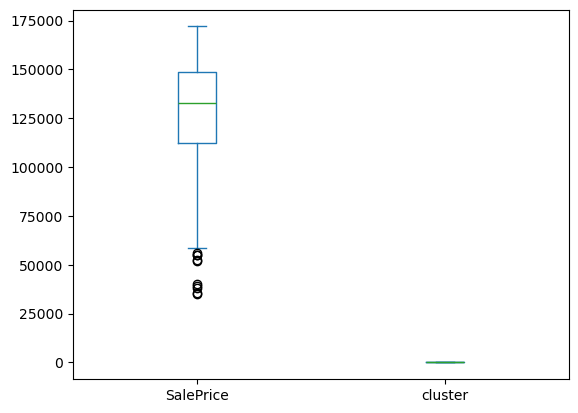

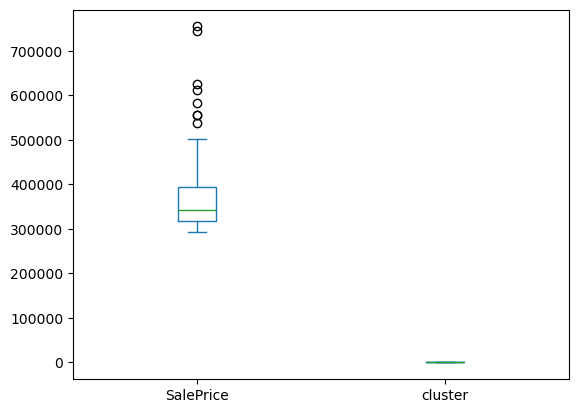

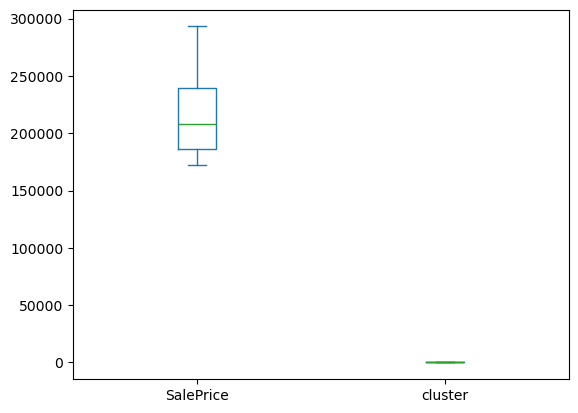

In [101]:
to_plot_cols = ['SalePrice', 'cluster']
to_plot = df_cluster[to_plot_cols].groupby('cluster')
to_plot.plot.box()

In [ ]:
'''
クラスタリングの結果、
0: SalePriceの値が高い群
1: 〃中間の群
2: 〃低い群

に分断された。

以下、グループ数２～５で実験してみる
'''

2グループに分けた場合の結果は以下


c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


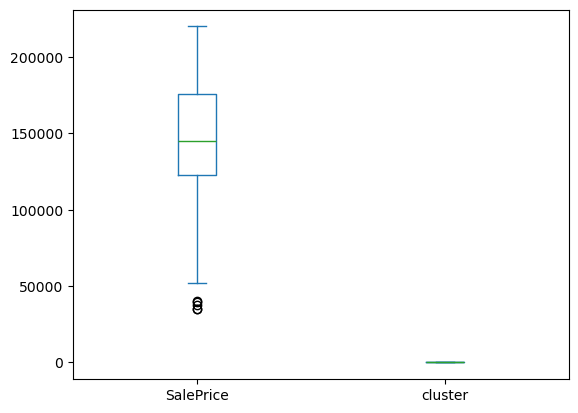

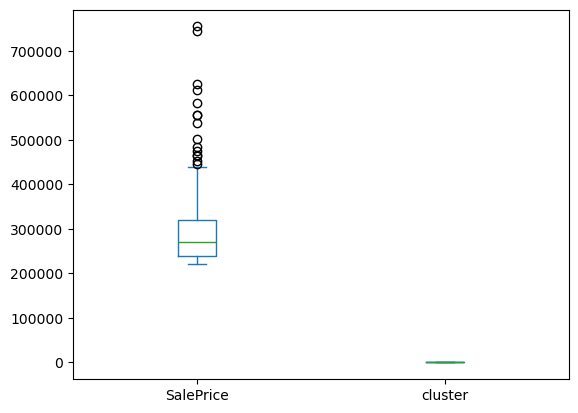

In [102]:
#クラスタリングによる分析
def cluster_and_box(i,df1):
    print(f'{i}グループに分けた場合の結果は以下')
    cluster_model = KMeans(n_clusters = i, random_state = 0)
    cluster_model.fit(df1)  #目的変数の列も含めてデータの全体的な傾向を見たいので、df1を使用
    df_cluster = df1.copy()
    df_cluster['cluster'] = cluster_model.labels_

    to_plot_cols = ['SalePrice', 'cluster']
    to_plot = df_cluster[to_plot_cols].groupby('cluster')
    to_plot.plot.box()


cluster_and_box(2,df1)

4グループに分けた場合の結果は以下


c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


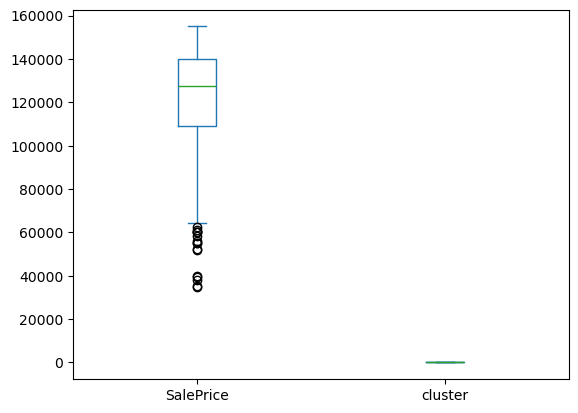

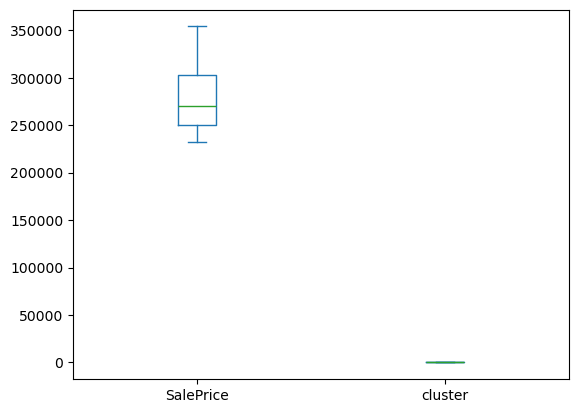

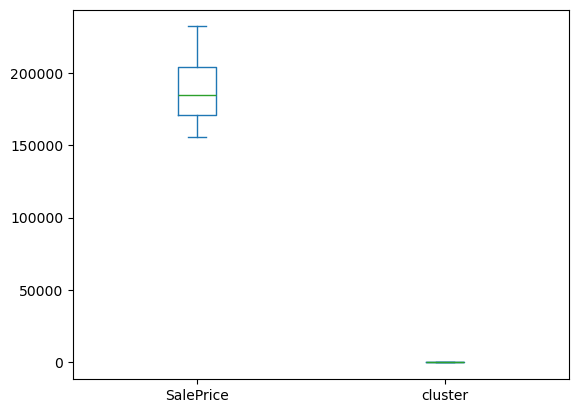

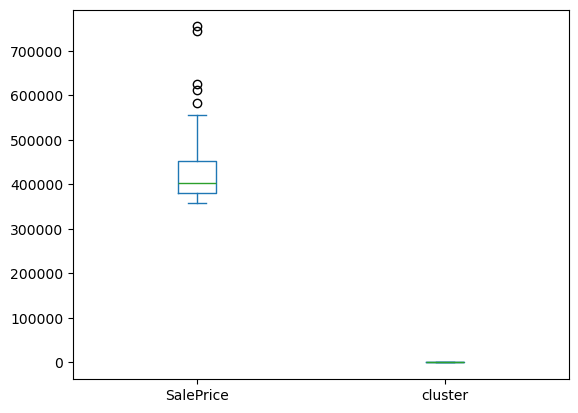

In [103]:
cluster_and_box(4,df1)

5グループに分けた場合の結果は以下


c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


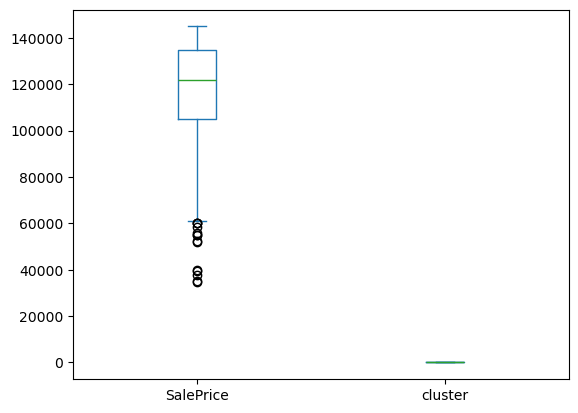

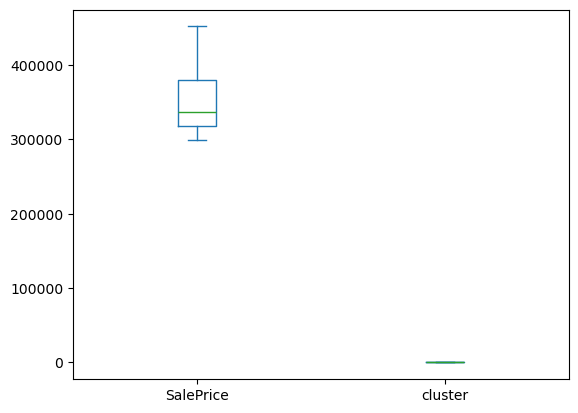

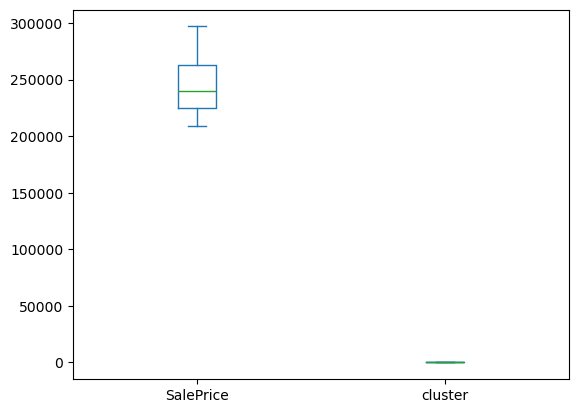

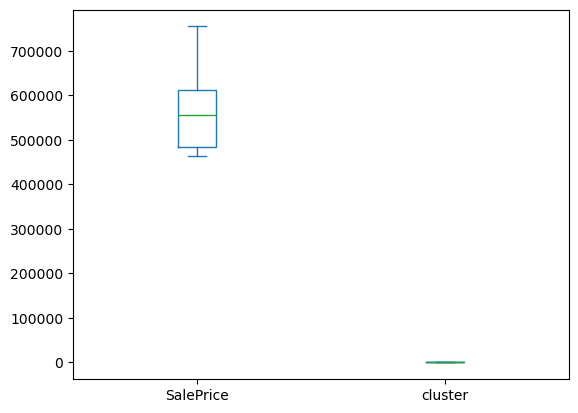

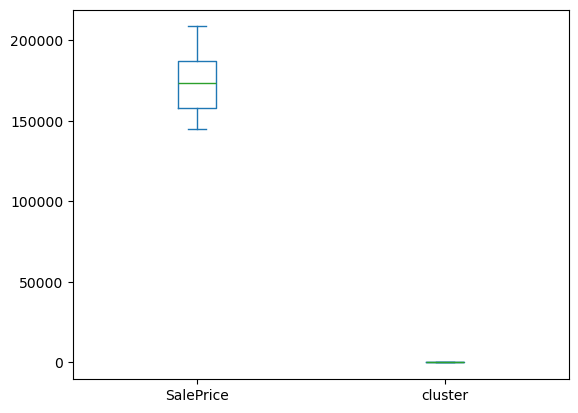

In [104]:
cluster_and_box(5,df1)

c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

<Axes: >

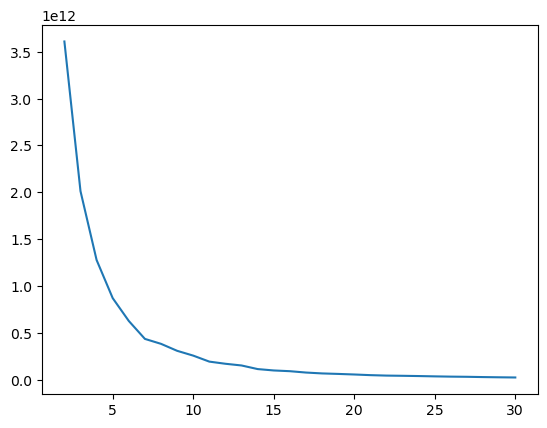

In [105]:
#SSEの調査
sse_list = []
for i in range(2,31):
    cluster_model = KMeans(n_clusters = i, random_state = 0)
    cluster_model.fit(df1)
    sse = cluster_model.inertia_
    sse_list.append(sse)

se = pd.Series(sse_list)
num = range(2,31)
se.index = num
se.plot(kind = 'line')

In [125]:
#sseは5~10で減少速度が大幅に低下している。以下では見通しが立てやすい3グループで考察を進める。
cluster_model = KMeans(n_clusters = 3, random_state = 0)
cluster_model.fit(df1)  #目的変数の列も含めてデータの全体的な傾向を見たいので、df1を使用
df_cluster = df1.copy()
df_cluster['cluster'] = cluster_model.labels_

c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [127]:
df_to_check = pd.concat([df_cluster[to_PCA],df_cluster['cluster']], axis = 1)

In [128]:
print('平均値')
df_to_check.groupby('cluster').mean()


平均値


,BsmtQual_NA,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscFeature_NA,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC
cluster,,,,,,,,,,,
0,0.124720,-0.239900,-0.270973,0.118754,-0.064327,-0.053035,-0.035867,-0.068624,0.030471,0.070132,-0.026180
1,-0.161250,0.811324,0.622391,-0.215022,0.061375,0.079940,0.046462,0.195977,-0.037037,-0.186352,-0.026180
2,-0.149445,0.175884,0.264123,-0.128607,0.081931,0.061017,0.042958,0.058350,-0.037037,-0.062734,0.044735


In [131]:
print('最頻値')
df_to_check.groupby('cluster').agg(
    lambda x: x.mode()
)

最頻値


,BsmtQual_NA,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscFeature_NA,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC
cluster,,,,,,,,,,,
0,-0.16125,-0.752176,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,0.195977,-0.037037,-0.186352,-0.02618
1,-0.16125,-0.752176,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,0.195977,-0.037037,-0.186352,-0.02618
2,-0.16125,-0.752176,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,0.195977,-0.037037,-0.186352,-0.02618


In [ ]:
print(df1['BsmtQual_NA'].unique())


[-0.16124951  6.20156911]


In [ ]:
'''
※df1は標準化後のデータフレームである。例えばBsmtQual_NA列(ダミー変数)では 0が-0.16124951、1が6.20156911と表記されている。

・最頻値はどのグループでも同じであった。
・箱ひげ図より、
    0: SalePriceの値が高い群
    1: 〃中間の群
    2: 〃低い群
    に分類された。仮説通り、確かに
    ・0群では「地下室がある・ウッドデッキが少ない・EnclosedPorchが多い、MiscFeature(生活に必須でない設備)を備えている」
    ・1群では「ウッドデッキが多い・OpenPorchが多い」
    といった傾向が見られた。
・一方、０群ではプールの面積が狭いなど、仮説に反する要素もあった。これは、SalePriceが高い0群には戸建てが多いため、
　集合住宅に備え付けられたプールと比較して面積が狭くなったなどの交絡因子が存在する可能性がある。
'''

＃モデルのより細かなチューニング

In [137]:
best_alpha = 0
best_lassoscore = 0
#最適なalphaの探索
#alpha（Fの係数）を329付近で変化させて実験
for i in range(3280,3300):
    num = i/10
    lassoModel = Lasso(random_state = 0, alpha = num)
    all_result = cross_validate(lassoModel, sc_x1, df_y, cv = kf, scoring = 'r2', return_train_score = True)
    result = sum(all_result['test_score'])/len(all_result['test_score'])
    if result > best_lassoscore:
        best_lassoscore = result
        best_alpha = num
print(f'最適な正則化項＝{best_alpha}　ラッソ回帰の最高スコア＝{best_lassoscore}')
model6 =  Lasso(random_state = 0, alpha = best_alpha)

最適な正則化項＝329.1　ラッソ回帰の最高スコア＝0.8443814832248068


In [138]:
#最適なalphaの探索
#alpha（Fの係数）を329.1付近で変化させて実験
for i in range(32900,32920):
    num = i/100
    lassoModel = Lasso(random_state = 0, alpha = num)
    all_result = cross_validate(lassoModel, sc_x1, df_y, cv = kf, scoring = 'r2', return_train_score = True)
    result = sum(all_result['test_score'])/len(all_result['test_score'])
    if result > best_lassoscore:
        best_lassoscore = result
        best_alpha = num
print(f'最適な正則化項＝{best_alpha}　ラッソ回帰の最高スコア＝{best_lassoscore}')
model6 =  Lasso(random_state = 0, alpha = best_alpha)

最適な正則化項＝329.03　ラッソ回帰の最高スコア＝0.844381543715453


In [139]:
#モデルの完成
final_model = Lasso(random_state = 0, alpha = 329.03)
final_model.fit(sc_x1, df_y)

,alpha,329.03
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,0
,selection,'cyclic'


In [ ]:
#テストデータの前処理
df_test = pd.read_csv('datafiles/test.csv')